# Small-Scale Natural Language Autoencoder for SmolLM2 Activations

This notebook implements a small-scale approximation of Anthropic's Natural Language Autoencoder idea.

The goal is to test whether hidden activation vectors from a language model can be converted into natural-language descriptions and reconstructed back into activation vectors.

I implement two experiments:

1. KMeans + TF-IDF verbalizer baseline
2. Activation-neighbor LLM verbalizer

The main metric is Fraction of Variance Explained, or FVE.

In [4]:
!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib sentence-transformers

## Code: imports and settings

In [5]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"
DATASET_NAME = "roneneldan/TinyStories"

N_SAMPLES = 2000
MAX_LENGTH = 128
LAYER_IDX = 12

RANDOM_STATE = 0

print("Device:", DEVICE)

Device: cuda


## load model and dataset

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    output_hidden_states=True
).to(DEVICE)

model.eval()

dataset = load_dataset(DATASET_NAME, split=f"train[:{N_SAMPLES}]")
texts = [x["text"][:1000] for x in dataset]

print("Number of texts:", len(texts))
print("Number of hidden layers:", model.config.num_hidden_layers)
print("Using layer:", LAYER_IDX)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Number of texts: 2000
Number of hidden layers: 30
Using layer: 12


## extract activation vectors

In [7]:
def extract_activations(texts, layer_idx=LAYER_IDX, max_length=MAX_LENGTH):
    activations = []

    model.eval()

    with torch.no_grad():
        for i, text in enumerate(texts):
            if i % 100 == 0:
                print("Extracting activation", i, "/", len(texts))

            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length
            ).to(DEVICE)

            outputs = model(**inputs, output_hidden_states=True)

            h = (
                outputs.hidden_states[layer_idx][0, -1, :]
                .detach()
                .cpu()
                .float()
                .numpy()
            )

            activations.append(h)

    return np.stack(activations)


activations = extract_activations(texts)

print("Activation shape:", activations.shape)

Extracting activation 0 / 2000
Extracting activation 100 / 2000
Extracting activation 200 / 2000
Extracting activation 300 / 2000
Extracting activation 400 / 2000
Extracting activation 500 / 2000
Extracting activation 600 / 2000
Extracting activation 700 / 2000
Extracting activation 800 / 2000
Extracting activation 900 / 2000
Extracting activation 1000 / 2000
Extracting activation 1100 / 2000
Extracting activation 1200 / 2000
Extracting activation 1300 / 2000
Extracting activation 1400 / 2000
Extracting activation 1500 / 2000
Extracting activation 1600 / 2000
Extracting activation 1700 / 2000
Extracting activation 1800 / 2000
Extracting activation 1900 / 2000
Activation shape: (2000, 576)


## Baseline Method: KMeans + TF-IDF Verbalizer

This first method is a statistical proxy, not a full reproduction of Anthropic's verbalizer.

Pipeline:

```text
input text
-> SmolLM2 activation vector
-> KMeans cluster
-> TF-IDF keywords from texts in that cluster
-> explanation sentence
-> Ridge regression reconstructor
-> reconstructed activation vector

In [8]:


## Cell 7 — Code: helper functions

def compute_fve(H_true, H_pred, H_train):
    """
    Fraction of Variance Explained.

    FVE = 1.0 means perfect reconstruction.
    FVE = 0.0 means same as predicting the train-set mean.
    FVE < 0.0 means worse than the mean baseline.
    """
    mean_train = H_train.mean(axis=0)
    sse = ((H_true - H_pred) ** 2).sum()
    sst = ((H_true - mean_train) ** 2).sum()
    return 1 - sse / sst


def compute_mean_cosine(H_true, H_pred):
    scores = []

    for i in range(len(H_true)):
        score = cosine_similarity(
            H_true[i].reshape(1, -1),
            H_pred[i].reshape(1, -1)
        )[0, 0]

        scores.append(score)

    return float(np.mean(scores))


def make_cluster_explanations(train_texts, train_clusters, K):
    """
    KMeans gives clusters.
    TF-IDF gives important words for the texts inside each cluster.
    """
    tfidf = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        min_df=2
    )

    X_text = tfidf.fit_transform(train_texts)
    terms = np.array(tfidf.get_feature_names_out())

    explanations = {}

    for c in range(K):
        idx = np.where(train_clusters == c)[0]

        if len(idx) == 0:
            explanations[c] = "This activation has no clear topic."
            continue

        scores = np.asarray(X_text[idx].mean(axis=0)).ravel()
        top_words = terms[scores.argsort()[-8:][::-1]]

        explanations[c] = (
            "This activation is from text about "
            + ", ".join(top_words[:6])
            + "."
        )

    return explanations

## full KMeans + TF-IDF experiment

In [9]:
def run_kmeans_tfidf_experiment(texts, activations, K=32, test_size=0.2, random_state=0):
    indices = np.arange(len(texts))

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state
    )

    train_texts = [texts[i] for i in train_idx]
    test_texts = [texts[i] for i in test_idx]

    H_train = activations[train_idx]
    H_test = activations[test_idx]

    # Fit KMeans only on train activations.
    kmeans = KMeans(
        n_clusters=K,
        random_state=random_state,
        n_init=10
    )

    train_clusters = kmeans.fit_predict(H_train)
    test_clusters = kmeans.predict(H_test)

    # Verbalizer: cluster -> TF-IDF explanation.
    cluster_explanations = make_cluster_explanations(
        train_texts,
        train_clusters,
        K
    )

    train_explanations = [cluster_explanations[c] for c in train_clusters]
    test_explanations = [cluster_explanations[c] for c in test_clusters]

    # Reconstructor: explanation text -> activation.
    text_vectorizer = TfidfVectorizer()
    X_train = text_vectorizer.fit_transform(train_explanations)
    X_test = text_vectorizer.transform(test_explanations)

    reconstructor = Ridge(alpha=1.0)
    reconstructor.fit(X_train, H_train)

    H_pred = reconstructor.predict(X_test)

    fve_text = compute_fve(H_test, H_pred, H_train)
    cosine_text = compute_mean_cosine(H_test, H_pred)

    # Baseline 1: mean predictor.
    H_mean_pred = np.repeat(
        H_train.mean(axis=0, keepdims=True),
        len(H_test),
        axis=0
    )

    fve_mean = compute_fve(H_test, H_mean_pred, H_train)

    # Baseline 2: cluster centroid predictor.
    cluster_centroids = {}

    for c in range(K):
        idx = np.where(train_clusters == c)[0]

        if len(idx) > 0:
            cluster_centroids[c] = H_train[idx].mean(axis=0)
        else:
            cluster_centroids[c] = H_train.mean(axis=0)

    H_centroid_pred = np.stack([
        cluster_centroids[c] for c in test_clusters
    ])

    fve_centroid = compute_fve(H_test, H_centroid_pred, H_train)

    # Baseline 3: original prompt text -> activation.
    prompt_vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        min_df=2
    )

    X_prompt_train = prompt_vectorizer.fit_transform(train_texts)
    X_prompt_test = prompt_vectorizer.transform(test_texts)

    prompt_reconstructor = Ridge(alpha=1.0)
    prompt_reconstructor.fit(X_prompt_train, H_train)

    H_prompt_pred = prompt_reconstructor.predict(X_prompt_test)

    fve_prompt = compute_fve(H_test, H_prompt_pred, H_train)

    per_sample_mse = ((H_test - H_pred) ** 2).mean(axis=1)

    per_sample_cosine = np.array([
        cosine_similarity(
            H_test[i].reshape(1, -1),
            H_pred[i].reshape(1, -1)
        )[0, 0]
        for i in range(len(H_test))
    ])

    return {
        "K": K,
        "fve_text_explanation": fve_text,
        "fve_mean_baseline": fve_mean,
        "fve_cluster_centroid": fve_centroid,
        "fve_prompt_text_baseline": fve_prompt,
        "mean_sample_mse": float(per_sample_mse.mean()),
        "mean_sample_cosine": cosine_text,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "test_clusters": test_clusters,
        "test_explanations": test_explanations,
        "H_train": H_train,
        "H_test": H_test,
        "H_pred": H_pred,
        "per_sample_mse": per_sample_mse,
        "per_sample_cosine": per_sample_cosine,
        "cluster_explanations": cluster_explanations
    }

In [10]:
main_result = run_nla_experiment(
    texts=texts,
    activations=activations,
    K=32,
    test_size=0.2,
    random_state=0
)

print("Text explanation FVE:", main_result["fve_text_explanation"])
print("Mean baseline FVE:", main_result["fve_mean_baseline"])
print("Cluster centroid baseline FVE:", main_result["fve_cluster_centroid"])
print("Prompt text baseline FVE:", main_result["fve_prompt_text_baseline"])
print("Mean cosine similarity:", main_result["mean_sample_cosine"])

Text explanation FVE: 0.39224477285158466
Mean baseline FVE: 0.0
Cluster centroid baseline FVE: 0.39215034
Prompt text baseline FVE: -0.10354869294564506
Mean cosine similarity: 0.8554757609698068


In [11]:
K_values = [8, 16, 32, 64, 128]

rows = []

for K in K_values:
    print("Running K =", K)

    result = run_nla_experiment(
        texts=texts,
        activations=activations,
        K=K,
        test_size=0.2,
        random_state=0
    )

    rows.append({
        "K": K,
        "fve_text_explanation": result["fve_text_explanation"],
        "fve_mean_baseline": result["fve_mean_baseline"],
        "fve_cluster_centroid": result["fve_cluster_centroid"],
        "fve_prompt_text_baseline": result["fve_prompt_text_baseline"],
        "mean_sample_mse": result["mean_sample_mse"],
        "mean_sample_cosine": result["mean_sample_cosine"]
    })

results_k = pd.DataFrame(rows)
results_k

Running K = 8
Running K = 16
Running K = 32
Running K = 64
Running K = 128


,K,fve_text_explanation,fve_mean_baseline,fve_cluster_centroid,fve_prompt_text_baseline,mean_sample_mse,mean_sample_cosine
0,8,0.279921,0.0,0.280320,-0.103549,10.674896,0.821362
1,16,0.343510,0.0,0.343715,-0.103549,9.732211,0.840140
2,32,0.392245,0.0,0.392150,-0.103549,9.009740,0.855476
3,64,0.445799,0.0,0.445299,-0.103549,8.215826,0.870073
4,128,0.492431,0.0,0.490724,-0.103549,7.524514,0.883201


## run main baseline experiment

In [10]:
main_result = run_kmeans_tfidf_experiment(
    texts=texts,
    activations=activations,
    K=128,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("K:", main_result["K"])
print("Text explanation FVE:", main_result["fve_text_explanation"])
print("Mean baseline FVE:", main_result["fve_mean_baseline"])
print("Cluster centroid baseline FVE:", main_result["fve_cluster_centroid"])
print("Prompt text baseline FVE:", main_result["fve_prompt_text_baseline"])
print("Mean cosine similarity:", main_result["mean_sample_cosine"])

K: 128
Text explanation FVE: 0.4938892445945484
Mean baseline FVE: 0.0
Cluster centroid baseline FVE: 0.49180973
Prompt text baseline FVE: -0.11649516586194952
Mean cosine similarity: 0.8904589435100896


## K sweep

In [11]:
K_values = [8, 16, 32, 64, 128]

rows = []

for K in K_values:
    print("Running K =", K)

    result = run_kmeans_tfidf_experiment(
        texts=texts,
        activations=activations,
        K=K,
        test_size=0.2,
        random_state=RANDOM_STATE
    )

    rows.append({
        "K": K,
        "fve_text_explanation": result["fve_text_explanation"],
        "fve_mean_baseline": result["fve_mean_baseline"],
        "fve_cluster_centroid": result["fve_cluster_centroid"],
        "fve_prompt_text_baseline": result["fve_prompt_text_baseline"],
        "mean_sample_mse": result["mean_sample_mse"],
        "mean_sample_cosine": result["mean_sample_cosine"]
    })

results_k = pd.DataFrame(rows)
results_k

Running K = 8
Running K = 16
Running K = 32
Running K = 64
Running K = 128


,K,fve_text_explanation,fve_mean_baseline,fve_cluster_centroid,fve_prompt_text_baseline,mean_sample_mse,mean_sample_cosine
0,8,0.235158,0.0,0.235243,-0.116495,10.151093,0.820602
1,16,0.236229,0.0,0.308290,-0.116495,10.136869,0.822725
2,32,0.334044,0.0,0.385363,-0.116495,8.838661,0.850012
3,64,0.449785,0.0,0.449607,-0.116495,7.302531,0.878798
4,128,0.493889,0.0,0.491810,-0.116495,6.717173,0.890459


## plot FVE by number of clusters

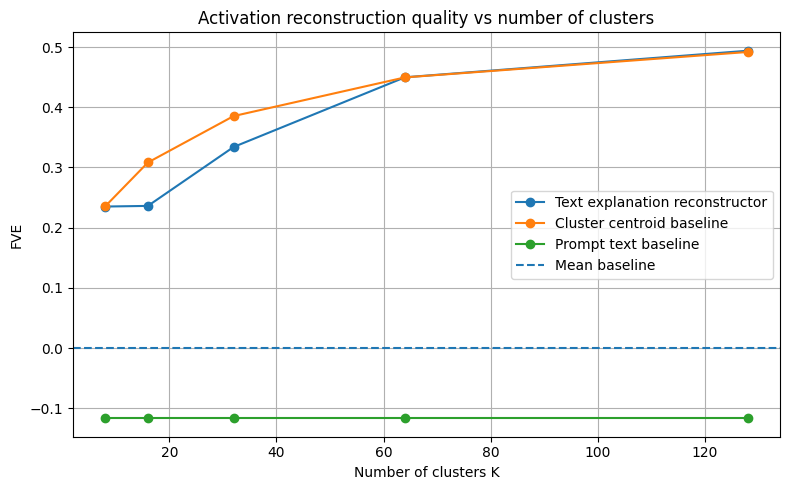

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_k["K"],
    results_k["fve_text_explanation"],
    marker="o",
    label="Text explanation reconstructor"
)

plt.plot(
    results_k["K"],
    results_k["fve_cluster_centroid"],
    marker="o",
    label="Cluster centroid baseline"
)

plt.plot(
    results_k["K"],
    results_k["fve_prompt_text_baseline"],
    marker="o",
    label="Prompt text baseline"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Mean baseline"
)

plt.xlabel("Number of clusters K")
plt.ylabel("FVE")
plt.title("Activation reconstruction quality vs number of clusters")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("fve_by_cluster_count.png", dpi=200)
plt.show()

## reconstruction error plot

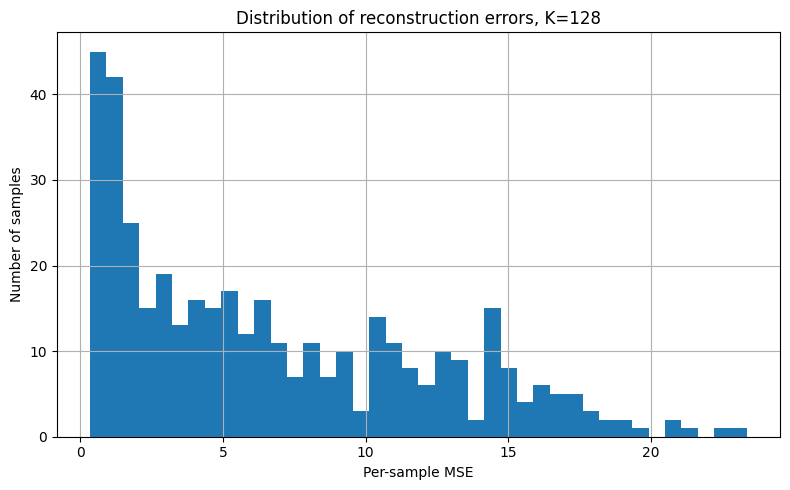

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    main_result["per_sample_mse"],
    bins=40
)

plt.xlabel("Per-sample MSE")
plt.ylabel("Number of samples")
plt.title("Distribution of reconstruction errors, K=128")
plt.grid(True)
plt.tight_layout()

plt.savefig("reconstruction_error_distribution_k128.png", dpi=200)
plt.show()

## qualitative examples

In [15]:
test_indices = main_result["test_idx"]
test_explanations = main_result["test_explanations"]
test_clusters = main_result["test_clusters"]
per_sample_mse = main_result["per_sample_mse"]
per_sample_cosine = main_result["per_sample_cosine"]

examples_all = []

for i in range(len(test_indices)):
    original_index = test_indices[i]

    examples_all.append({
        "original_text": texts[original_index][:500],
        "cluster": int(test_clusters[i]),
        "explanation": test_explanations[i],
        "mse": float(per_sample_mse[i]),
        "cosine_similarity": float(per_sample_cosine[i])
    })

examples_all_df = pd.DataFrame(examples_all)

best_examples = examples_all_df.sort_values(
    "cosine_similarity",
    ascending=False
).head(5)

worst_examples = examples_all_df.sort_values(
    "cosine_similarity",
    ascending=True
).head(5)

best_examples.to_csv("best_examples_k128.csv", index=False)
worst_examples.to_csv("worst_examples_k128.csv", index=False)

print("Best examples")
display(best_examples)

print("Worst examples")
display(worst_examples)

Best examples


,original_text,cluster,explanation,mse,cosine_similarity
348,Once there was a city full of people. Everyone...,63,"This activation is from text about end, boy, c...",0.414261,0.990371
180,"Once upon a time, there was a big white dog na...",2,"This activation is from text about timmy, day,...",0.333094,0.990334
40,"Once upon a time, there was a little boy named...",2,"This activation is from text about timmy, day,...",0.403427,0.988714
134,"Once upon a time, a little girl was trying to ...",63,"This activation is from text about end, boy, c...",0.464666,0.988554
328,"Once upon a time, in a gloomy forest, there wa...",25,"This activation is from text about switch, gra...",0.794712,0.987518


Worst examples


,original_text,cluster,explanation,mse,cosine_similarity
8,"Once upon a time, there was a family of birds....",67,"This activation is from text about prince, liz...",22.411926,0.644349
258,"Once upon a time, there was an old man. He had...",72,"This activation is from text about man, angel,...",17.612737,0.658034
223,"Once upon a time, there was a chubby cat. He w...",0,"This activation is from text about said, mom, ...",23.359616,0.670076
11,"Once upon a time, there was a brave pink rabbi...",68,"This activation is from text about hippo, ball...",14.353891,0.693090
339,Once upon a time there was an orange needle ca...,108,"This activation is from text about sock, spide...",17.552168,0.694319


## Baseline Interpretation

The KMeans + TF-IDF verbalizer achieved its best result with K=128.

The text-explanation reconstructor recovered about 49% of activation variance. This is clearly better than the mean baseline.

However, the text-explanation result is almost identical to the cluster-centroid baseline. This means the generated explanation mostly encodes cluster membership. Since all samples in the same cluster receive the same explanation, the reconstructor is close to predicting the average activation of that cluster.

Therefore, this method should be treated as a baseline, not a faithful reproduction of Anthropic's activation verbalizer.

# Improved method: activation-neighbor LLM verbalizer

## Improved Method: Activation-Neighbor LLM Verbalizer

The previous method used TF-IDF keywords, so it did not use an actual language model as the verbalizer.

This second method is closer to the paper:

```text
activation vector
-> nearest activation neighbors
-> neighbor text contexts
-> instruction LLM generates free-text explanation
-> sentence embedding of explanation
-> Ridge reconstructor
-> reconstructed activation

In [16]:


## Cell 16 — Code: load local instruction model

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

VERBALIZER_MODEL = "google/flan-t5-base"

verb_tokenizer = AutoTokenizer.from_pretrained(VERBALIZER_MODEL)
verb_model = AutoModelForSeq2SeqLM.from_pretrained(VERBALIZER_MODEL).to(DEVICE)

verb_model.eval()

print("Loaded verbalizer model:", VERBALIZER_MODEL)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded verbalizer model: google/flan-t5-base


## LLM explanation functions

In [17]:
def make_prompt_from_neighbors(neighbor_texts):
    snippets = []

    for i, text in enumerate(neighbor_texts):
        clean = text.replace("\n", " ")
        clean = clean[:300]
        snippets.append(f"{i+1}. {clean}")

    joined = "\n".join(snippets)

    prompt = f"""
You are describing a hidden activation inside a language model.

The activation is similar to activations produced by these text contexts:

{joined}

Write one short explanation of the common feature this hidden activation may represent.
Do not simply repeat the texts. Describe the shared semantic or structural pattern.

Explanation:
"""

    return prompt


def generate_explanation(neighbor_texts, max_new_tokens=50):
    prompt = make_prompt_from_neighbors(neighbor_texts)

    inputs = verb_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        output = verb_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    explanation = verb_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    return explanation.strip()

## test the LLM verbalizer

In [18]:
test_neighbor_texts = texts[:5]

print(generate_explanation(test_neighbor_texts))

The cobweb is a common feature of language models.


## build activation-neighbor data

In [19]:
def build_neighbor_indices(texts, activations, n_neighbors=8, test_size=0.2, random_state=0):
    indices = np.arange(len(texts))

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state
    )

    H_train = activations[train_idx]
    H_test = activations[test_idx]

    train_texts = [texts[i] for i in train_idx]
    test_texts = [texts[i] for i in test_idx]

    nn = NearestNeighbors(
        n_neighbors=n_neighbors + 1,
        metric="cosine"
    )

    nn.fit(H_train)

    train_neighbors_raw = nn.kneighbors(H_train, return_distance=False)
    train_neighbors = train_neighbors_raw[:, 1:n_neighbors + 1]

    test_neighbors = nn.kneighbors(
        H_test,
        n_neighbors=n_neighbors,
        return_distance=False
    )

    return {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "H_train": H_train,
        "H_test": H_test,
        "train_texts": train_texts,
        "test_texts": test_texts,
        "train_neighbors": train_neighbors,
        "test_neighbors": test_neighbors
    }


neighbor_data = build_neighbor_indices(
    texts=texts,
    activations=activations,
    n_neighbors=8,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train activations:", neighbor_data["H_train"].shape)
print("Test activations:", neighbor_data["H_test"].shape)

Train activations: (1600, 576)
Test activations: (400, 576)


## generate LLM explanations

In [20]:
def generate_neighbor_explanations(base_texts, neighbor_indices, limit=None):
    explanations = []

    total = len(neighbor_indices) if limit is None else min(limit, len(neighbor_indices))

    for i in range(total):
        if i % 50 == 0:
            print("Generating explanation", i, "/", total)

        neigh = neighbor_indices[i]
        neighbor_texts = [base_texts[j] for j in neigh]

        explanation = generate_explanation(neighbor_texts)
        explanations.append(explanation)

    return explanations


N_TRAIN_LLM = 800
N_TEST_LLM = 200

train_explanations_llm = generate_neighbor_explanations(
    neighbor_data["train_texts"],
    neighbor_data["train_neighbors"],
    limit=N_TRAIN_LLM
)

test_explanations_llm = generate_neighbor_explanations(
    neighbor_data["train_texts"],
    neighbor_data["test_neighbors"],
    limit=N_TEST_LLM
)

pd.DataFrame({"explanation": train_explanations_llm}).to_csv(
    "train_llm_explanations.csv",
    index=False
)

pd.DataFrame({"explanation": test_explanations_llm}).to_csv(
    "test_llm_explanations.csv",
    index=False
)

print("Saved LLM explanations.")

Generating explanation 0 / 800
Generating explanation 50 / 800
Generating explanation 100 / 800
Generating explanation 150 / 800
Generating explanation 200 / 800
Generating explanation 250 / 800
Generating explanation 300 / 800
Generating explanation 350 / 800
Generating explanation 400 / 800
Generating explanation 450 / 800
Generating explanation 500 / 800
Generating explanation 550 / 800
Generating explanation 600 / 800
Generating explanation 650 / 800
Generating explanation 700 / 800
Generating explanation 750 / 800
Generating explanation 0 / 200
Generating explanation 50 / 200
Generating explanation 100 / 200
Generating explanation 150 / 200
Saved LLM explanations.


## inspect LLM explanations

In [21]:
for i in range(10):
    print("Example", i)
    print(test_explanations_llm[i])
    print()

Example 0
Ben was interested in the doll.

Example 1
candy

Example 2
bac

Example 3
Chloe was excited to explore the world.

Example 4
The girl's dizzyness caused her to fall to the ground.

Example 5
He poked the lollipop with his finger.

Example 6
Billy was always a patient boy.

Example 7
to the nearest house.

Example 8
a good time.

Example 9
a man who was very excited. He wanted to explore the jungle. One day, he saw a strange bird, who spoke to the bird. One day, he asked his maid for some special makeup. "I want to



## reconstruct from LLM explanations

In [22]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=DEVICE
)

H_train_llm = neighbor_data["H_train"][:N_TRAIN_LLM]
H_test_llm = neighbor_data["H_test"][:N_TEST_LLM]

X_train_llm = embedder.encode(
    train_explanations_llm,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)

X_test_llm = embedder.encode(
    test_explanations_llm,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)

reconstructor_llm = Ridge(alpha=1.0)
reconstructor_llm.fit(X_train_llm, H_train_llm)

H_pred_llm = reconstructor_llm.predict(X_test_llm)

fve_llm = compute_fve(H_test_llm, H_pred_llm, H_train_llm)
cosine_llm = compute_mean_cosine(H_test_llm, H_pred_llm)

print("LLM verbalizer FVE:", fve_llm)
print("LLM verbalizer mean cosine:", cosine_llm)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

LLM verbalizer FVE: -0.07898688
LLM verbalizer mean cosine: 0.733518123626709


## nearest-neighbor centroid baseline

In [23]:
test_neighbors_subset = neighbor_data["test_neighbors"][:N_TEST_LLM]

H_nn_centroid_pred = np.stack([
    neighbor_data["H_train"][neigh].mean(axis=0)
    for neigh in test_neighbors_subset
])

fve_nn_centroid = compute_fve(
    H_test_llm,
    H_nn_centroid_pred,
    H_train_llm
)

cosine_nn_centroid = compute_mean_cosine(
    H_test_llm,
    H_nn_centroid_pred
)

print("LLM verbalizer FVE:", fve_llm)
print("Nearest-neighbor centroid FVE:", fve_nn_centroid)

print("LLM verbalizer mean cosine:", cosine_llm)
print("Nearest-neighbor centroid mean cosine:", cosine_nn_centroid)

LLM verbalizer FVE: -0.07898688
Nearest-neighbor centroid FVE: 0.5974874
LLM verbalizer mean cosine: 0.733518123626709
Nearest-neighbor centroid mean cosine: 0.9151824712753296


## compare all main results

In [24]:
summary_rows = [
    {
        "method": "Mean baseline",
        "FVE": main_result["fve_mean_baseline"],
        "mean_cosine": np.nan
    },
    {
        "method": "Prompt text TF-IDF baseline",
        "FVE": main_result["fve_prompt_text_baseline"],
        "mean_cosine": np.nan
    },
    {
        "method": "KMeans + TF-IDF explanation, K=128",
        "FVE": main_result["fve_text_explanation"],
        "mean_cosine": main_result["mean_sample_cosine"]
    },
    {
        "method": "KMeans cluster centroid baseline, K=128",
        "FVE": main_result["fve_cluster_centroid"],
        "mean_cosine": np.nan
    },
    {
        "method": "Activation-neighbor LLM verbalizer",
        "FVE": fve_llm,
        "mean_cosine": cosine_llm
    },
    {
        "method": "Nearest-neighbor centroid baseline",
        "FVE": fve_nn_centroid,
        "mean_cosine": cosine_nn_centroid
    }
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("summary_results.csv", index=False)

summary_df

,method,FVE,mean_cosine
0,Mean baseline,0.000000,NaN
1,Prompt text TF-IDF baseline,-0.116495,NaN
2,"KMeans + TF-IDF explanation, K=128",0.493889,0.890459
3,"KMeans cluster centroid baseline, K=128",0.491810,NaN
4,Activation-neighbor LLM verbalizer,-0.078987,0.733518
5,Nearest-neighbor centroid baseline,0.597487,0.915182


## save all outputs into folders

In [25]:
os.makedirs("results/figures", exist_ok=True)

files_to_move = [
    "fve_by_cluster_count.png",
    "reconstruction_error_distribution_k128.png",
    "best_examples_k128.csv",
    "worst_examples_k128.csv",
    "train_llm_explanations.csv",
    "test_llm_explanations.csv",
    "summary_results.csv"
]

results_k.to_csv("fve_by_cluster_count.csv", index=False)
files_to_move.append("fve_by_cluster_count.csv")

for file in files_to_move:
    if os.path.exists(file):
        if file.endswith(".png"):
            target = f"results/figures/{file}"
        else:
            target = f"results/{file}"

        if os.path.exists(target):
            os.remove(target)

        shutil.move(file, target)

print("Results folder:")
print(os.listdir("results"))

print("Figures folder:")
print(os.listdir("results/figures"))

Results folder:
['test_llm_explanations.csv', 'worst_examples_k128.csv', 'figures', 'fve_by_cluster_count.csv', 'best_examples_k128.csv', 'train_llm_explanations.csv', 'summary_results.csv']
Figures folder:
['fve_by_cluster_count.png', 'reconstruction_error_distribution_k128.png']


In [26]:
requirements = """
transformers
datasets
accelerate
torch
scikit-learn
pandas
numpy
matplotlib
sentence-transformers
""".strip()

with open("requirements.txt", "w") as f:
    f.write(requirements)

print(requirements)

transformers
datasets
accelerate
torch
scikit-learn
pandas
numpy
matplotlib
sentence-transformers


## Final Interpretation

This project has two parts.

First, I implemented a KMeans + TF-IDF baseline. It achieved strong reconstruction numbers, with FVE around 0.49 for K=128. However, the result was almost identical to the cluster-centroid baseline. This means the explanation mostly encodes cluster identity rather than a detailed natural-language description of each individual activation.

Second, I added an activation-neighbor LLM verbalizer. This method retrieves nearest neighbors in activation space and asks an instruction model to generate a free-text explanation of the shared pattern. This is closer to the Natural Language Autoencoder idea because the bottleneck is actual generated language.

This is still not a full reproduction of Anthropic's method. I do not inject activation vectors directly into the verbalizer model, and I do not train the verbalizer using RL. The contribution is a small, honest, reproducible study showing what works in a simplified setting and where the simplifications fail.